# Automated Maize Leaf Disease Detection using Deep Learning

### Vision Transformer (ViT-B/16) tuned with the Grey Wolf Optimizer (GWO), benchmarked against MobileNetV2 / VGG16 / ResNet50, with a GWO-weighted SqueezeNet late-fusion stream

**Dataset:** CCMT Crop Pest & Disease Dataset (Kaggle, `irakozekelly/crop-pest-and-disease-dataset`) — **Maize** subset, four disease/healthy classes (Leaf Blight, Leaf Spot, Maize Streak Virus, Healthy).

This notebook implements the full pipeline described in the project proposal:

1. Dataset download & analysis (class distribution, samples)
2. Field-image **preprocessing** (segmentation, CLAHE, color-constancy, denoising)
3. **Augmentation** (training set only, imbalance handling)
4. **Stratified** 70 / 15 / 15 split
5. **ViT-B/16** primary model (transfer learning)
6. **GWO hyperparameter tuning** — *2 candidate values per hyperparameter, 3 epochs per candidate evaluation*
7. CNN baselines (MobileNetV2 / VGG16 / ResNet50)
8. **Decision-level SqueezeNet fusion** with GWO-optimized fusion weight (no-compromise guarantee)
9. Stage-by-stage **visualizations** (charts **and** matplotlib tables) + full metric suite

> **Runtime note:** this is compute-heavy and expects a **GPU runtime** (Google Colab / Kaggle). For a fast end-to-end smoke test, set `QUICK_TEST = True` in the configuration cell.

## 0. Environment setup & configuration

In [ ]:
# Crop Pest and Disease Dataset (CCMT) — Kaggle

In [1]:
# Install required packages (safe to re-run).
# torch / torchvision are pre-installed on Colab & Kaggle; we only add the rest.
!pip -q install kagglehub

In [2]:
import os, glob, time, random, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, f1_score)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings('ignore')

# ---------- Reproducibility ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| Device:', device)

# ================= GLOBAL CONFIGURATION (edit here) =================
IMG_SIZE = 224
TARGET_CLASSES = ['leaf blight', 'leaf spot', 'streak virus', 'healthy', 'fall armyworm', 'grasshoper']   # 4 disease/healthy classes
CLASS_DISPLAY  = {'leaf blight':'Leaf Blight', 'leaf spot':'Leaf Spot',
                  'streak virus':'Maize Streak Virus', 'healthy':'Healthy',
                  'fall armyworm':'Fall Armyworm', 'grasshoper':'Grasshoper'}

USE_AUGMENTED_FOLDER      = False   # False -> Raw field images (+ our own augmentation), matches the proposal
USE_SEGMENTATION_IN_PIPELINE = False  # heavy; demonstrated on samples, kept off in the training pipeline for speed

# ---- GWO hyperparameter-search budget (kept intentionally small, per project spec) ----
GWO_POP_SIZE     = 5      # number of wolves (candidates per iteration)
GWO_ITERATIONS   = 2      # GWO iterations
TUNE_EPOCHS      = 2      # epochs trained per candidate evaluation  (spec: 2)
TUNE_SUBSET_FRAC = 0.35   # fraction of the train set used during tuning (speed)

# ---- Final training budget ----
FINAL_EPOCHS        = 10
EARLY_STOP_PATIENCE = 5
DEFAULT_BATCH       = 32

TUNE_BASELINES = False    # optionally GWO-tune CNN baselines too (expensive); off by default

# ---- Fast smoke test ----
QUICK_TEST = False
if QUICK_TEST:
    GWO_POP_SIZE=3; GWO_ITERATIONS=2; TUNE_EPOCHS=2
    FINAL_EPOCHS=4; TUNE_SUBSET_FRAC=0.20; EARLY_STOP_PATIENCE=3

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

PyTorch: 2.11.0+cu128 | Device: cuda


In [3]:
# Helper: render a pandas DataFrame as a matplotlib TABLE (tabular visualization used at every stage)
def render_table(df, title='', col_width=2.2, row_height=0.5, fontsize=10):
    data = df.copy()
    ncols, nrows = len(data.columns), len(data)
    fig, ax = plt.subplots(figsize=(min(16, col_width*ncols), row_height*(nrows+1)+0.7))
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=fontsize+3, fontweight='bold', pad=12)
    tbl = ax.table(cellText=data.values.astype(str), colLabels=data.columns,
                   cellLoc='center', loc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(fontsize); tbl.scale(1, 1.45)
    for j in range(ncols):
        c = tbl[0, j]; c.set_facecolor('#2f5d50'); c.set_text_props(color='white', fontweight='bold')
    for i in range(1, nrows+1):
        for j in range(ncols):
            tbl[i, j].set_facecolor('#f4f7f6' if i % 2 else '#e8eeec')
    plt.tight_layout(); plt.show()

def load_rgb(fp):
    img = cv2.imread(fp)
    return None if img is None else cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

## 1. Problem statement (recap)

Maize yield is heavily affected by foliar disease, and manual diagnosis is slow and expertise-dependent. We build an image classifier that identifies the disease state of a maize leaf from a single **field-condition** photograph. The primary model is a **Vision Transformer** whose hyperparameters are tuned by a **swarm metaheuristic (Grey Wolf Optimizer)**, benchmarked against three CNN backbones, and additively enhanced by a lightweight **SqueezeNet** stream fused at the decision level with GWO-optimized weights.

## 2. Dataset download & discovery

We download the CCMT dataset with `kagglehub`, locate the **Maize** directory, and keep the four disease/healthy folders. Class folders are matched by keyword (robust to minor naming differences), so the three *pest* folders (fall armyworm, grasshopper, leaf beetle) are automatically excluded from this 4-class task.

In [4]:
import kagglehub
path = kagglehub.dataset_download("irakozekelly/crop-pest-and-disease-dataset")
print("Path to dataset files:", path)

100%|██████████| 7.87G/7.87G [07:32<00:00, 18.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/irakozekelly/crop-pest-and-disease-dataset/versions/1


In [5]:
# Locate the Maize directory (raw field images by default).
def find_maize_dir(root, use_augmented=False):
    candidates = []
    for dirpath, dirnames, _ in os.walk(root):
        if os.path.basename(dirpath).lower() == 'maize':
            candidates.append(dirpath)
    if not candidates:
        raise FileNotFoundError('No "Maize" folder found under ' + root)
    aug = [c for c in candidates if 'augment' in c.lower()]
    raw = [c for c in candidates if 'augment' not in c.lower()]
    return (aug or candidates)[0] if use_augmented else (raw or candidates)[0]

maize_dir = find_maize_dir(path, USE_AUGMENTED_FOLDER)
print('Using Maize directory:', maize_dir)
print('Sub-folders found     :', sorted(os.listdir(maize_dir)))

Using Maize directory: /root/.cache/kagglehub/datasets/irakozekelly/crop-pest-and-disease-dataset/versions/1/Dataset for Crop Pest and Disease Detection/Raw Data/CCMT Dataset/Maize
Sub-folders found     : ['fall armyworm', 'grasshoper', 'healthy', 'leaf beetle', 'leaf blight', 'leaf spot', 'streak virus']


In [6]:
# Map raw class-folder names -> our 4 target classes by keyword.
def match_target_class(folder_name):
    n = folder_name.lower()
    if 'blight' in n:  return 'leaf blight'
    if 'spot'   in n:  return 'leaf spot'
    if 'streak' in n:  return 'streak virus'
    if 'health' in n:  return 'healthy'
    if 'fall armyworm' in n:  return 'fall armyworm'
    if 'grasshoper' in n:  return 'grasshoper'
    return None  # pest / other -> excluded

rows = []
for folder in sorted(os.listdir(maize_dir)):
    fpath = os.path.join(maize_dir, folder)
    if not os.path.isdir(fpath):
        continue
    tgt = match_target_class(folder)
    if tgt is None:
        continue
    imgs = []
    for ext in ('*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG'):
        imgs += glob.glob(os.path.join(fpath, ext))
    for im in imgs:
        rows.append({'filepath': im, 'class': tgt, 'source_folder': folder})

df = pd.DataFrame(rows).drop_duplicates('filepath').reset_index(drop=True)
print('Total images kept (6 classes):', len(df))
print(df['class'].value_counts())

Total images kept (6 classes): 4410
class
leaf spot        1259
leaf blight      1006
streak virus      979
grasshoper        673
fall armyworm     285
healthy           208
Name: count, dtype: int64


### 2.1 Dataset analysis — class distribution

The dataset is expected to be **class-imbalanced**; we quantify it here (handled later with class weights + macro-averaged metrics). Visualized as both a **table** and charts.

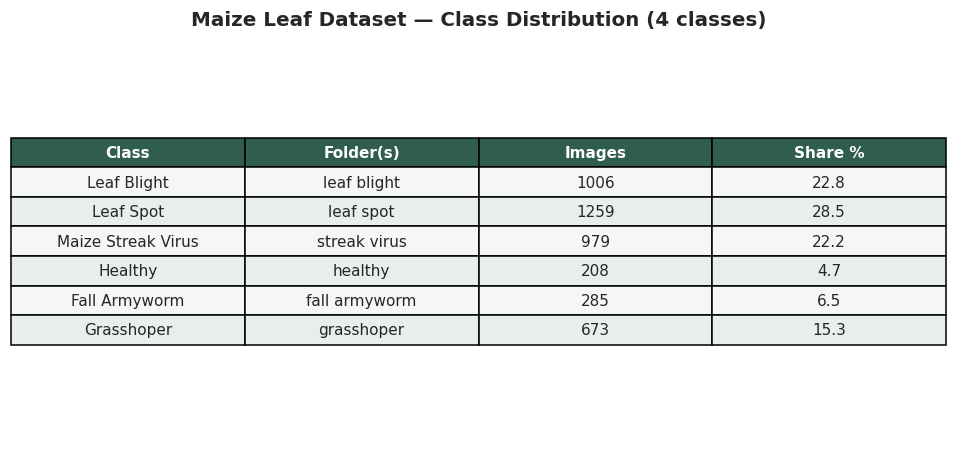

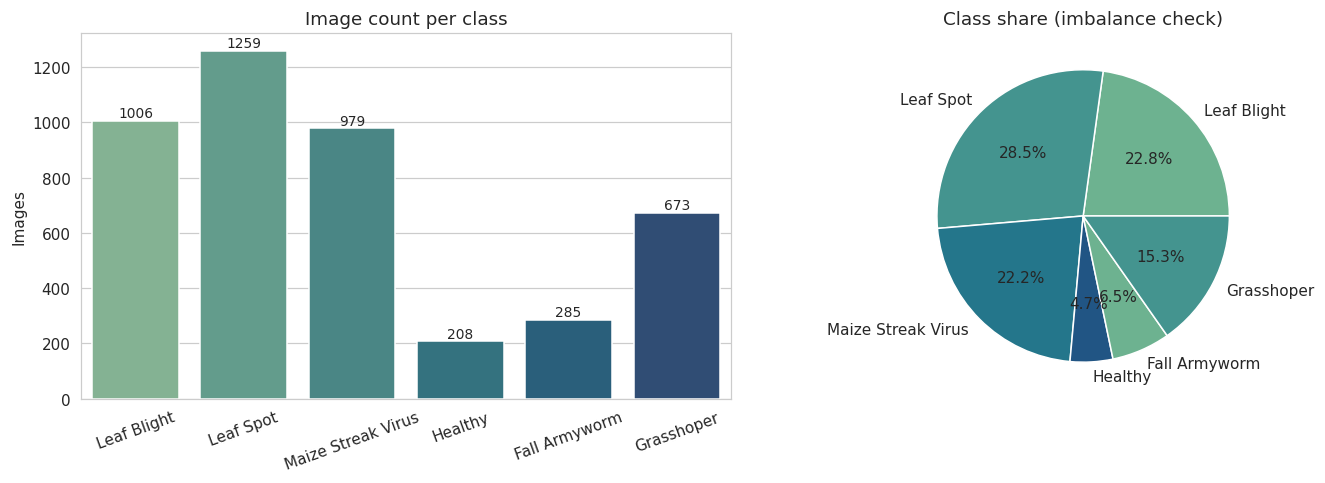

Imbalance ratio (max/min): 6.05


In [7]:
counts = df['class'].value_counts().reindex(TARGET_CLASSES)
dist = pd.DataFrame({
    'Class'    : [CLASS_DISPLAY[c] for c in TARGET_CLASSES],
    'Folder(s)': [', '.join(sorted(df[df['class']==c]['source_folder'].unique())) for c in TARGET_CLASSES],
    'Images'   : counts.values,
    'Share %'  : (counts.values / counts.values.sum() * 100).round(1),
})
render_table(dist, title='Maize Leaf Dataset — Class Distribution (4 classes)')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=[CLASS_DISPLAY[c] for c in TARGET_CLASSES], y=counts.values, ax=ax[0], palette='crest')
ax[0].set_title('Image count per class'); ax[0].set_ylabel('Images'); ax[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(counts.values):
    ax[0].text(i, v + max(counts.values)*0.01, str(v), ha='center', fontsize=9)
ax[1].pie(counts.values, labels=[CLASS_DISPLAY[c] for c in TARGET_CLASSES],
          autopct='%1.1f%%', colors=sns.color_palette('crest', 4))
ax[1].set_title('Class share (imbalance check)')
plt.tight_layout(); plt.show()

print(f'Imbalance ratio (max/min): {counts.max()/counts.min():.2f}')

In [8]:
# Grid of raw field sample images per class
fig, axes = plt.subplots(len(TARGET_CLASSES), 4, figsize=(12, 3*len(TARGET_CLASSES)))
for r, c in enumerate(TARGET_CLASSES):
    sub = df[df['class']==c]['filepath']
    samples = sub.sample(min(4, len(sub)), random_state=SEED).tolist()
    for k in range(4):
        ax = axes[r, k]; ax.axis('off')
        if k < len(samples):
            im = load_rgb(samples[k])
            if im is not None:
                ax.imshow(im)
        if k == 0:
            ax.set_title(CLASS_DISPLAY[c], loc='left', fontsize=11, fontweight='bold')
fig.suptitle('Raw field-collected sample images per class', y=1.001, fontsize=13)
plt.tight_layout(); plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 3. Methodology

### 3.1 Preprocessing & normalization

Field imagery needs a stronger pipeline than lab data: **leaf segmentation** (HSV thresholding), **color constancy** (Gray-World white balance), **illumination normalization** (CLAHE), and **edge-preserving denoising** (bilateral filter), then resize to 224×224. Each stage is visualized below.

In [9]:
def segment_leaf(img_rgb):
    # HSV green-thresholding to suppress cluttered field background
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    mask = cv2.inRange(hsv, np.array([15, 25, 25]), np.array([95, 255, 255]))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((5, 5), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))
    if mask.sum() < 0.05 * 255 * mask.size:      # fallback if the mask is too small
        return img_rgb
    out = img_rgb.copy(); out[mask == 0] = 0
    return out

def gray_world(img_rgb):
    img = img_rgb.astype(np.float32)
    mean = img.reshape(-1, 3).mean(0); g = mean.mean()
    return np.clip(img * (g / (mean + 1e-6)), 0, 255).astype(np.uint8)

def apply_clahe(img_rgb):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)

def denoise(img_rgb):
    return cv2.bilateralFilter(img_rgb, d=7, sigmaColor=50, sigmaSpace=50)

def preprocess_image(img_rgb, segment=False):
    if img_rgb is None:
        return None
    if segment:
        img_rgb = segment_leaf(img_rgb)
    img_rgb = gray_world(img_rgb)
    img_rgb = apply_clahe(img_rgb)
    img_rgb = denoise(img_rgb)
    return cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

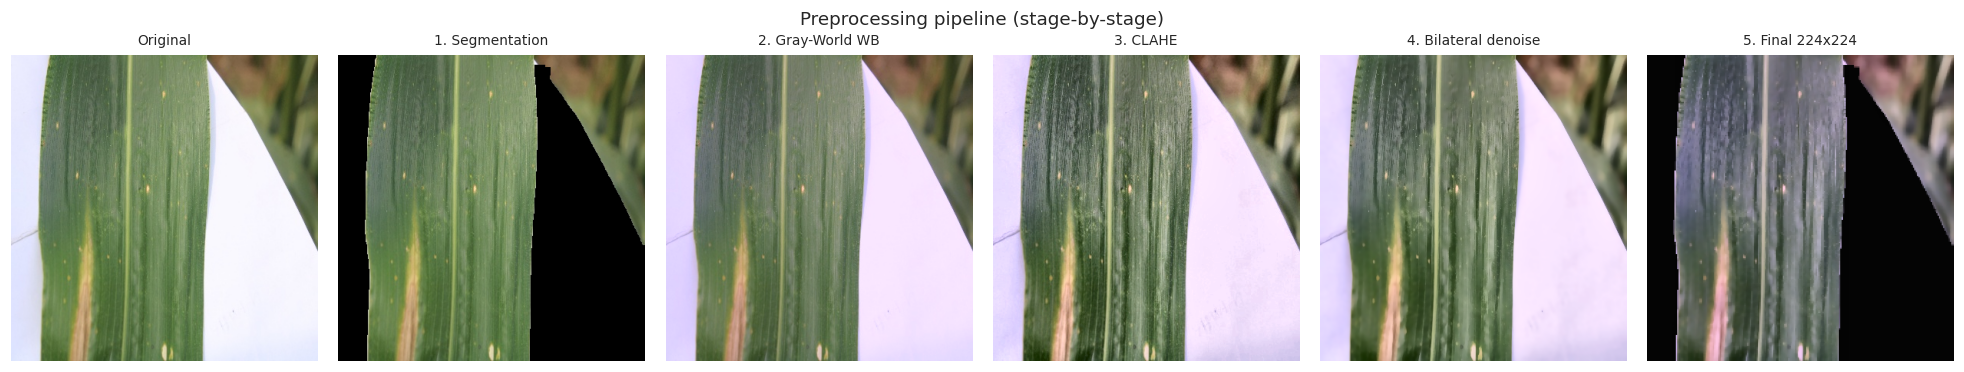

In [10]:
# Stage-by-stage before/after visualization on one sample
sample_fp = df['filepath'].sample(1, random_state=7).iloc[0]
orig = load_rgb(sample_fp)
steps = [
    ('Original',              orig),
    ('1. Segmentation',       segment_leaf(orig)),
    ('2. Gray-World WB',      gray_world(orig)),
    ('3. CLAHE',              apply_clahe(gray_world(orig))),
    ('4. Bilateral denoise',  denoise(apply_clahe(gray_world(orig)))),
    ('5. Final 224x224',      preprocess_image(orig, segment=True)),
]
fig, axes = plt.subplots(1, len(steps), figsize=(3*len(steps), 3.4))
for ax, (t, im) in zip(axes, steps):
    ax.imshow(im); ax.set_title(t, fontsize=9); ax.axis('off')
fig.suptitle('Preprocessing pipeline (stage-by-stage)', fontsize=12)
plt.tight_layout(); plt.show()

### 3.2 Data augmentation

Applied to the **training set only**. Rotation, flips, affine shift/zoom/shear, and brightness/contrast jitter. Minority classes are additionally emphasized through class weighting (Section 3.x).

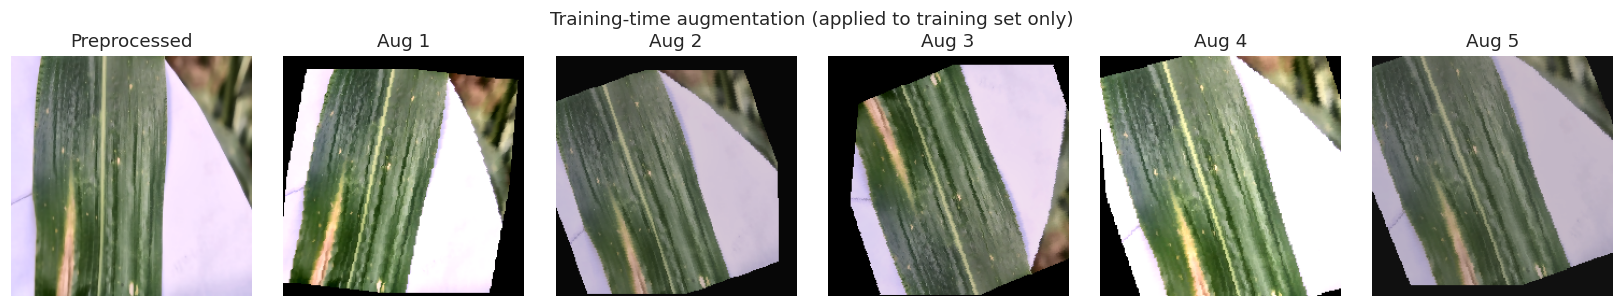

In [11]:
aug_demo = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(25),
    transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.85, 1.15), shear=8),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2),
])
base = preprocess_image(orig)
fig, axes = plt.subplots(1, 6, figsize=(15, 2.8))
axes[0].imshow(base); axes[0].set_title('Preprocessed'); axes[0].axis('off')
for k in range(1, 6):
    axes[k].imshow(np.array(aug_demo(base))); axes[k].set_title(f'Aug {k}'); axes[k].axis('off')
fig.suptitle('Training-time augmentation (applied to training set only)', fontsize=12)
plt.tight_layout(); plt.show()

### 3.3 Stratified train / validation / test split (70 / 15 / 15)

Class ratios are preserved in every split; the **test set is held out** and never touched during training or tuning.

Train / Val / Test : 3087 / 661 / 662


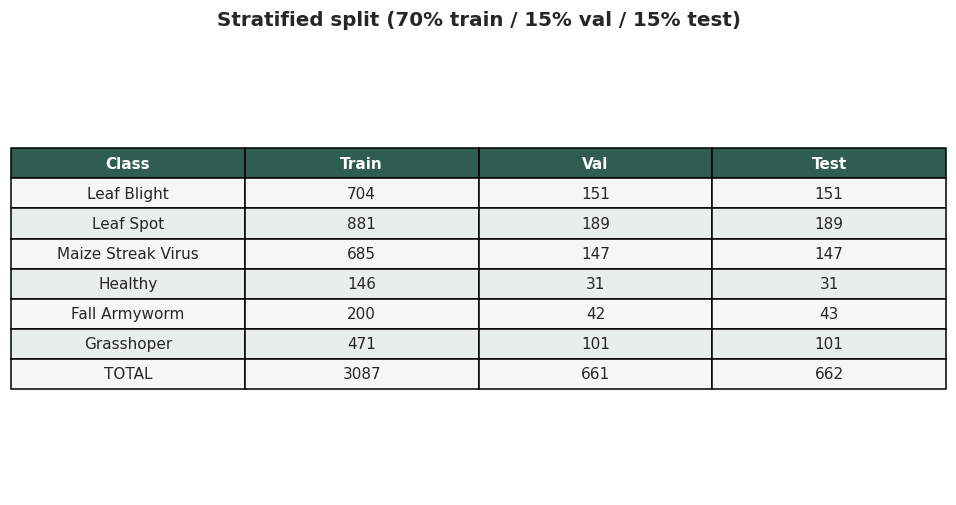

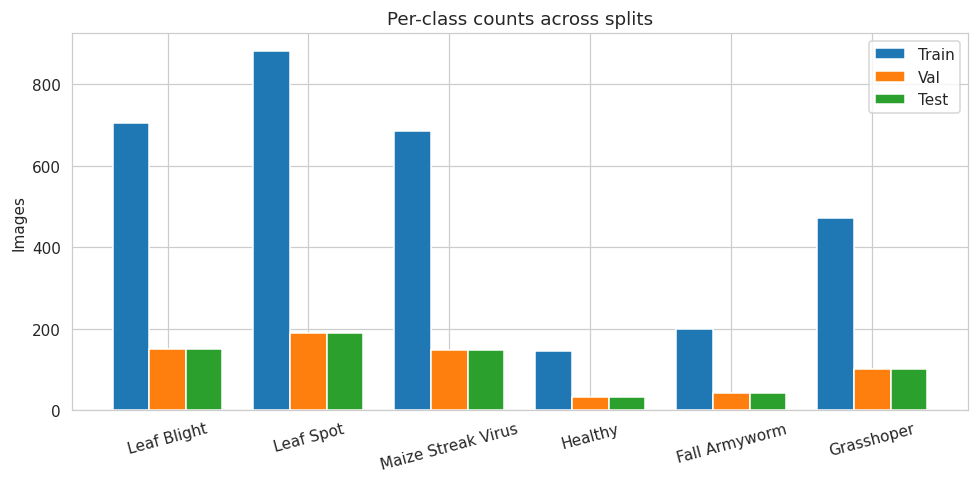

In [12]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['class'], random_state=SEED)
val_df,  test_df  = train_test_split(temp_df, test_size=0.50, stratify=temp_df['class'], random_state=SEED)
for d in (train_df, val_df, test_df):
    d.reset_index(drop=True, inplace=True)
print('Train / Val / Test :', len(train_df), '/', len(val_df), '/', len(test_df))

split_tbl = pd.DataFrame({
    'Class': [CLASS_DISPLAY[c] for c in TARGET_CLASSES],
    'Train': [int((train_df['class']==c).sum()) for c in TARGET_CLASSES],
    'Val'  : [int((val_df['class']==c).sum())   for c in TARGET_CLASSES],
    'Test' : [int((test_df['class']==c).sum())  for c in TARGET_CLASSES],
})
split_tbl.loc[len(split_tbl)] = ['TOTAL', split_tbl['Train'].sum(), split_tbl['Val'].sum(), split_tbl['Test'].sum()]
render_table(split_tbl, title='Stratified split (70% train / 15% val / 15% test)')

idx = np.arange(len(TARGET_CLASSES)); w = 0.26
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(idx-w, split_tbl['Train'][:-1], w, label='Train')
ax.bar(idx,   split_tbl['Val'][:-1],   w, label='Val')
ax.bar(idx+w, split_tbl['Test'][:-1],  w, label='Test')
ax.set_xticks(idx); ax.set_xticklabels([CLASS_DISPLAY[c] for c in TARGET_CLASSES], rotation=15)
ax.set_ylabel('Images'); ax.set_title('Per-class counts across splits'); ax.legend()
plt.tight_layout(); plt.show()

### 3.x Dataset object, transforms & class weights

A custom `Dataset` applies the OpenCV preprocessing on the fly, then torchvision transforms (augmentation for train; normalization for all). All pretrained backbones expect **ImageNet normalization**, applied consistently for a fair comparison. Class imbalance is handled via **class weights** in the loss.

In [13]:
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(25),
    transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.85, 1.15), shear=8),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class MaizeDataset(Dataset):
    def __init__(self, frame, transform, segment=USE_SEGMENTATION_IN_PIPELINE):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.segment = segment
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, i):
        row = self.frame.iloc[i]
        img = cv2.imread(row['filepath'])
        img = np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8) if img is None else cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = preprocess_image(img, segment=self.segment)
        return self.transform(img), CLASS_TO_IDX[row['class']]

# Class weights (inverse frequency) for imbalance handling
cls_counts = np.array([(train_df['class']==c).sum() for c in TARGET_CLASSES], dtype=np.float32)
class_weights = torch.tensor(cls_counts.sum() / (len(cls_counts) * cls_counts), dtype=torch.float32)
print('Class weights:', {c: round(float(w), 3) for c, w in zip(TARGET_CLASSES, class_weights)})

def make_loaders(batch_size, tune=False):
    tr = train_df
    if tune and TUNE_SUBSET_FRAC < 1.0:
        tr, _ = train_test_split(train_df, train_size=TUNE_SUBSET_FRAC,
                                 stratify=train_df['class'], random_state=SEED)
    tl = DataLoader(MaizeDataset(tr, train_tf), batch_size=batch_size, shuffle=True,
                    num_workers=2, pin_memory=True)
    vl = DataLoader(MaizeDataset(val_df, eval_tf), batch_size=batch_size, shuffle=False,
                    num_workers=2, pin_memory=True)
    return tl, vl

Class weights: {'leaf blight': 0.731, 'leaf spot': 0.584, 'streak virus': 0.751, 'healthy': 3.524, 'fall armyworm': 2.572, 'grasshoper': 1.092}


### 3.4 Model architectures

- **Primary:** ImageNet-pretrained **ViT-B/16** via transfer learning. Lower encoder blocks are frozen; the last *N* blocks + a new classification head (`Linear → ReLU → Dropout → Linear(4)`) are fine-tuned.
- **Baselines:** MobileNetV2, VGG16, ResNet50 — each with a fresh 4-class head, trained under the identical protocol.
- **Fusion stream:** SqueezeNet-1.1 (frozen features) with a 1×1-conv softmax head.

In [14]:
def build_vit(dropout=0.3, head_size=256, unfrozen_blocks=4):
    m = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False
    for blk in list(m.encoder.layers)[-unfrozen_blocks:]:      # unfreeze last N encoder blocks
        for p in blk.parameters():
            p.requires_grad = True
    for p in m.encoder.ln.parameters():
        p.requires_grad = True
    in_dim = m.heads.head.in_features
    m.heads = nn.Sequential(
        nn.Linear(in_dim, head_size), nn.ReLU(inplace=True),
        nn.Dropout(dropout), nn.Linear(head_size, len(TARGET_CLASSES)))
    return m

def build_cnn(name):
    if name == 'MobileNetV2':
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(TARGET_CLASSES))
    elif name == 'VGG16':
        m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, len(TARGET_CLASSES))
    elif name == 'ResNet50':
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, len(TARGET_CLASSES))
    else:
        raise ValueError(name)
    return m

def build_squeezenet():
    m = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.IMAGENET1K_V1)
    for p in m.features.parameters():           # frozen feature extractor
        p.requires_grad = False
    m.classifier[1] = nn.Conv2d(512, len(TARGET_CLASSES), kernel_size=1)
    m.num_classes = len(TARGET_CLASSES)
    return m

def count_params(m):
    return sum(p.numel() for p in m.parameters())

### 3.6 Training utilities

Categorical cross-entropy (class-weighted), **AdamW**, `ReduceLROnPlateau`, **early stopping**, and best-weight restoration by validation macro-F1.

In [15]:
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total, loss_sum, preds_all, labels_all = 0, 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward(); optimizer.step()
            loss_sum += loss.item() * x.size(0); total += x.size(0)
            preds_all.append(out.argmax(1).cpu().numpy()); labels_all.append(y.cpu().numpy())
    preds = np.concatenate(preds_all); labels = np.concatenate(labels_all)
    return (loss_sum/total,
            f1_score(labels, preds, average='macro'),
            accuracy_score(labels, preds))

def train_model(model, train_loader, val_loader, epochs, lr, weight_decay,
                use_class_weights=True, patience=EARLY_STOP_PATIENCE, verbose=True):
    model = model.to(device)
    w = class_weights.to(device) if use_class_weights else None
    criterion = nn.CrossEntropyLoss(weight=w)
    optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad],
                            lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    hist = {k: [] for k in ('train_loss','val_loss','train_f1','val_f1','train_acc','val_acc')}
    best_f1, best_state, no_improve = -1.0, None, 0
    for ep in range(epochs):
        tl, tf1, tacc = run_epoch(model, train_loader, criterion, optimizer)
        vl, vf1, vacc = run_epoch(model, val_loader,   criterion, None)
        scheduler.step(vl)
        hist['train_loss'].append(tl); hist['val_loss'].append(vl)
        hist['train_f1'].append(tf1);  hist['val_f1'].append(vf1)
        hist['train_acc'].append(tacc); hist['val_acc'].append(vacc)
        if verbose:
            print(f'  epoch {ep+1}/{epochs}  train_loss {tl:.3f}  val_loss {vl:.3f}  val_f1 {vf1:.3f}  val_acc {vacc:.3f}')
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose: print('  early stopping.')
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, hist, best_f1

def get_probs(model, loader):
    model.eval(); probs, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            probs.append(torch.softmax(out, 1).cpu().numpy()); labels.append(y.numpy())
    return np.concatenate(probs), np.concatenate(labels)

def plot_history(hist, title):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].plot(hist['train_loss'], label='train'); ax[0].plot(hist['val_loss'], label='val'); ax[0].set_title('Loss')
    ax[1].plot(hist['train_acc'],  label='train'); ax[1].plot(hist['val_acc'],  label='val'); ax[1].set_title('Accuracy')
    ax[2].plot(hist['train_f1'],   label='train'); ax[2].plot(hist['val_f1'],   label='val'); ax[2].set_title('Macro-F1')
    for a in ax:
        a.set_xlabel('epoch'); a.legend(); a.grid(True, alpha=0.3)
    fig.suptitle(title, fontsize=12); plt.tight_layout(); plt.show()

### 3.5 Hyperparameter tuning with the Grey Wolf Optimizer (GWO)

The ViT is tuned with **`mealpy`'s Grey Wolf Optimizer**. Per the project spec, each hyperparameter has **exactly 2 candidate values**, and every candidate is trained for **3 epochs** on a stratified subset of the training data. GWO's continuous variables are decoded to the discrete option index (`int(value) ∈ {0,1}`).

**Fitness:** each candidate returns validation **macro-F1**; since `mealpy` minimizes, the objective is `1 − macro-F1`.

In [16]:
# This cell is now redundant as mealpy installation is handled in the environment setup cell.
!pip install mealpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.3/423.3 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 109.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3

In [17]:
from mealpy import FloatVar, GWO

# Exactly 2 candidate values per hyperparameter (project spec)
SEARCH_SPACE = {
    'lr'             : [1e-4, 3e-5],
    'dropout'        : [0.2, 0.4],
    'batch_size'     : [16, 32],
    'unfrozen_blocks': [2, 4],
    'weight_decay'   : [1e-4, 1e-5],
    'head_size'      : [128, 256],
}
HP_KEYS = list(SEARCH_SPACE.keys())

def decode(solution):
    return {k: SEARCH_SPACE[k][int(v) % len(SEARCH_SPACE[k])] for k, v in zip(HP_KEYS, solution)}

tuning_log = []
def vit_fitness(solution):
    hp = decode(solution)
    tl, vl = make_loaders(hp['batch_size'], tune=True)
    model = build_vit(dropout=hp['dropout'], head_size=hp['head_size'],
                      unfrozen_blocks=hp['unfrozen_blocks'])
    _, _, best_f1 = train_model(model, tl, vl, epochs=TUNE_EPOCHS,
                                lr=hp['lr'], weight_decay=hp['weight_decay'],
                                patience=TUNE_EPOCHS, verbose=False)
    tuning_log.append({**hp, 'val_macro_f1': round(best_f1, 4)})
    print('  evaluated', hp, '-> val_macro_f1', round(best_f1, 4))
    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    return 1.0 - best_f1                       # minimize

problem = {
    'obj_func': vit_fitness,
    'bounds'  : FloatVar(lb=[0.0]*len(HP_KEYS), ub=[1.999]*len(HP_KEYS)),
    'minmax'  : 'min',
    'log_to'  : None,
}
print('Running Grey Wolf Optimizer (trains many short ViTs; be patient)...')
gwo = GWO.OriginalGWO(epoch=GWO_ITERATIONS, pop_size=GWO_POP_SIZE)
best_agent = gwo.solve(problem)

best_hp = decode(best_agent.solution)
print('\nBest hyperparameters      :', best_hp)
print('Best validation macro-F1  :', round(1 - best_agent.target.fitness, 4))

Running Grey Wolf Optimizer (trains many short ViTs; be patient)...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 137MB/s]


  evaluated {'lr': 3e-05, 'dropout': 0.4, 'batch_size': 32, 'unfrozen_blocks': 4, 'weight_decay': 0.0001, 'head_size': 256} -> val_macro_f1 0.7179
  evaluated {'lr': 0.0001, 'dropout': 0.2, 'batch_size': 16, 'unfrozen_blocks': 2, 'weight_decay': 0.0001, 'head_size': 128} -> val_macro_f1 0.7514
  evaluated {'lr': 3e-05, 'dropout': 0.2, 'batch_size': 32, 'unfrozen_blocks': 2, 'weight_decay': 1e-05, 'head_size': 128} -> val_macro_f1 0.6474
  evaluated {'lr': 3e-05, 'dropout': 0.4, 'batch_size': 16, 'unfrozen_blocks': 4, 'weight_decay': 1e-05, 'head_size': 256} -> val_macro_f1 0.7703
  evaluated {'lr': 3e-05, 'dropout': 0.4, 'batch_size': 32, 'unfrozen_blocks': 4, 'weight_decay': 0.0001, 'head_size': 256} -> val_macro_f1 0.688
  evaluated {'lr': 0.0001, 'dropout': 0.4, 'batch_size': 16, 'unfrozen_blocks': 4, 'weight_decay': 0.0001, 'head_size': 256} -> val_macro_f1 0.8025
  evaluated {'lr': 0.0001, 'dropout': 0.4, 'batch_size': 16, 'unfrozen_blocks': 2, 'weight_decay': 0.0001, 'head_size':

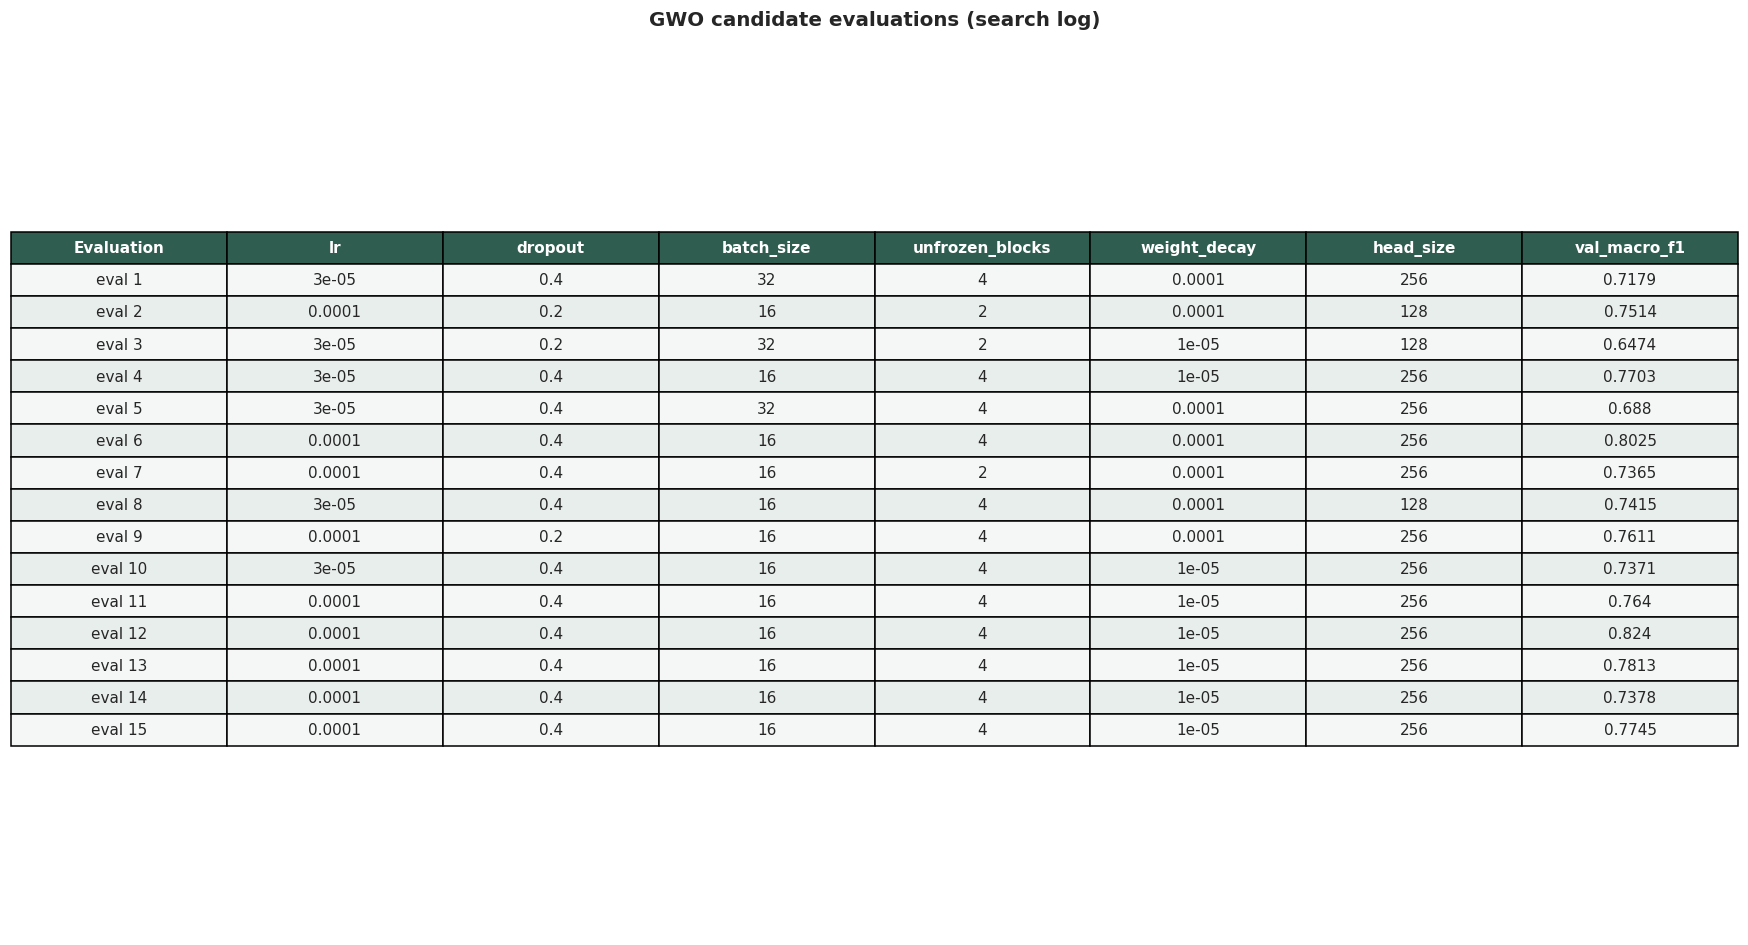

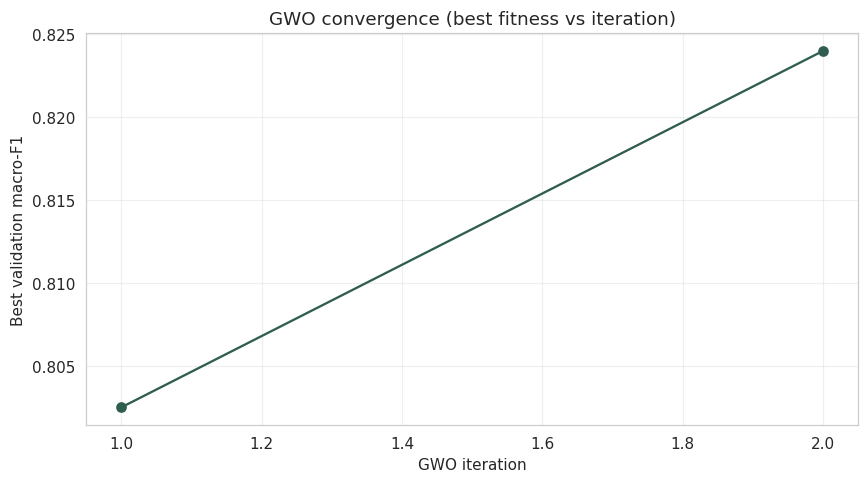

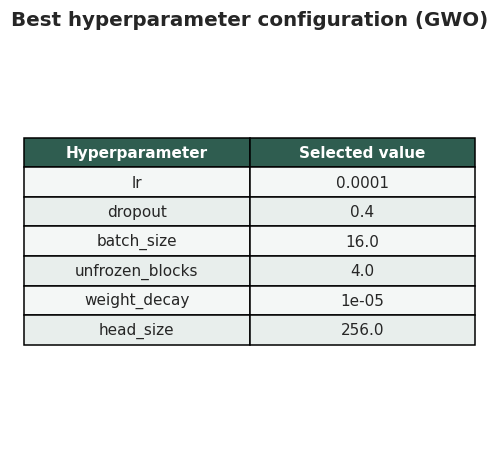

In [18]:
# GWO search log (table) + convergence curve + best-config table
tune_tbl = pd.DataFrame(tuning_log)
tune_tbl.insert(0, 'Evaluation', ['eval '+str(i+1) for i in range(len(tune_tbl))])
render_table(tune_tbl, title='GWO candidate evaluations (search log)')

try:
    conv = gwo.history.list_global_best_fit
except Exception:
    conv = None
if conv:
    conv_f1 = [1 - c for c in conv]
    plt.figure(figsize=(8, 4.5))
    plt.plot(range(1, len(conv_f1)+1), conv_f1, marker='o', color='#2f5d50')
    plt.xlabel('GWO iteration'); plt.ylabel('Best validation macro-F1')
    plt.title('GWO convergence (best fitness vs iteration)')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

render_table(pd.DataFrame({'Hyperparameter': list(best_hp.keys()),
                           'Selected value': [best_hp[k] for k in best_hp]}),
             title='Best hyperparameter configuration (GWO)')

### Final ViT training (best GWO configuration, full budget)

Training final ViT with best GWO hyperparameters...
  epoch 1/5  train_loss 0.739  val_loss 0.475  val_f1 0.805  val_acc 0.788
  epoch 2/5  train_loss 0.382  val_loss 0.400  val_f1 0.805  val_acc 0.794
  epoch 3/5  train_loss 0.324  val_loss 0.402  val_f1 0.814  val_acc 0.809
  epoch 4/5  train_loss 0.294  val_loss 0.357  val_f1 0.867  val_acc 0.841
  epoch 5/5  train_loss 0.254  val_loss 0.364  val_f1 0.851  val_acc 0.825
ViT best val macro-F1: 0.8669


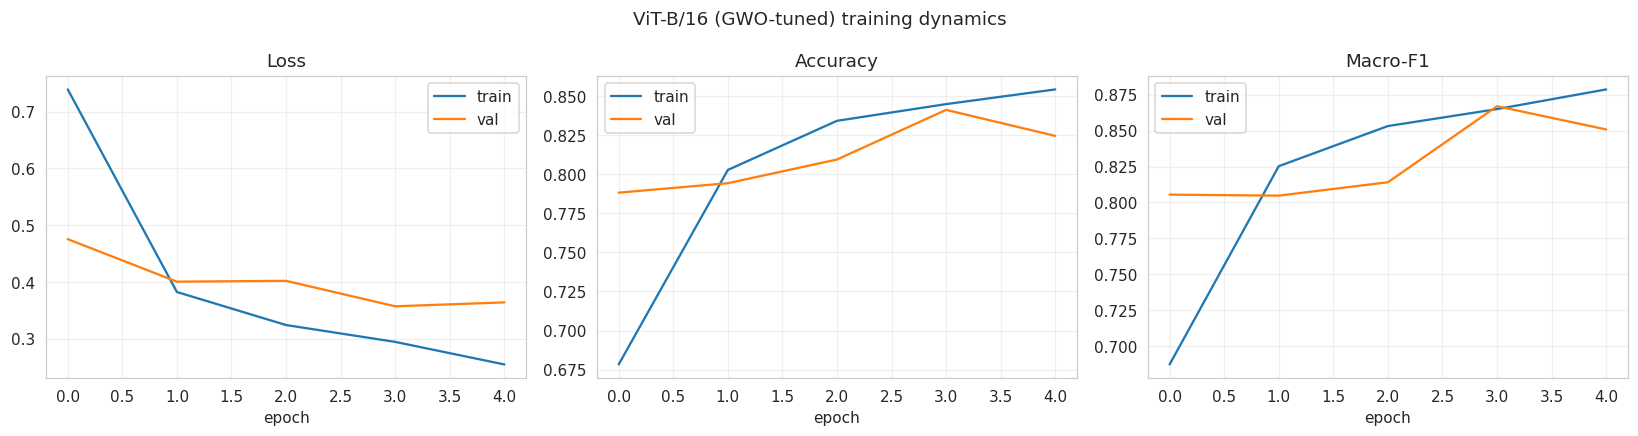

In [19]:
print('Training final ViT with best GWO hyperparameters...')
train_loader, val_loader = make_loaders(best_hp['batch_size'], tune=False)
vit = build_vit(dropout=best_hp['dropout'], head_size=best_hp['head_size'],
                unfrozen_blocks=best_hp['unfrozen_blocks'])
vit, vit_hist, vit_bestf1 = train_model(vit, train_loader, val_loader, epochs=FINAL_EPOCHS,
                                        lr=best_hp['lr'], weight_decay=best_hp['weight_decay'])
print('ViT best val macro-F1:', round(vit_bestf1, 4))
plot_history(vit_hist, 'ViT-B/16 (GWO-tuned) training dynamics')

### CNN baselines (MobileNetV2 / VGG16 / ResNet50)

Trained under the same split, augmentation and evaluation protocol. (Set `TUNE_BASELINES = True` to also GWO-tune each baseline for an equal-budget comparison.)

Training MobileNetV2  (hp={'lr': 0.0001, 'weight_decay': 0.0001, 'batch_size': 32}) ...
  epoch 1/2  train_loss 0.842  val_loss 0.519  val_f1 0.771  val_acc 0.762
  epoch 2/2  train_loss 0.473  val_loss 0.456  val_f1 0.806  val_acc 0.781
MobileNetV2 val macro-F1: 0.8057


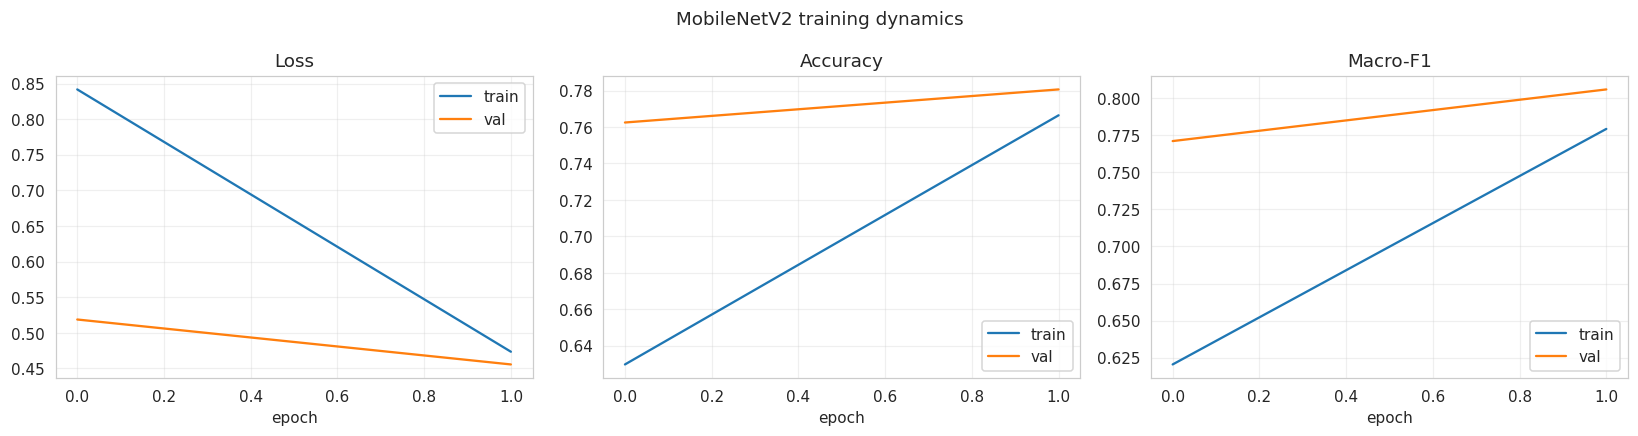

Training VGG16  (hp={'lr': 0.0001, 'weight_decay': 0.0001, 'batch_size': 32}) ...
  epoch 1/2  train_loss 1.103  val_loss 0.754  val_f1 0.658  val_acc 0.658
  epoch 2/2  train_loss 0.668  val_loss 0.632  val_f1 0.733  val_acc 0.719
VGG16 val macro-F1: 0.7333


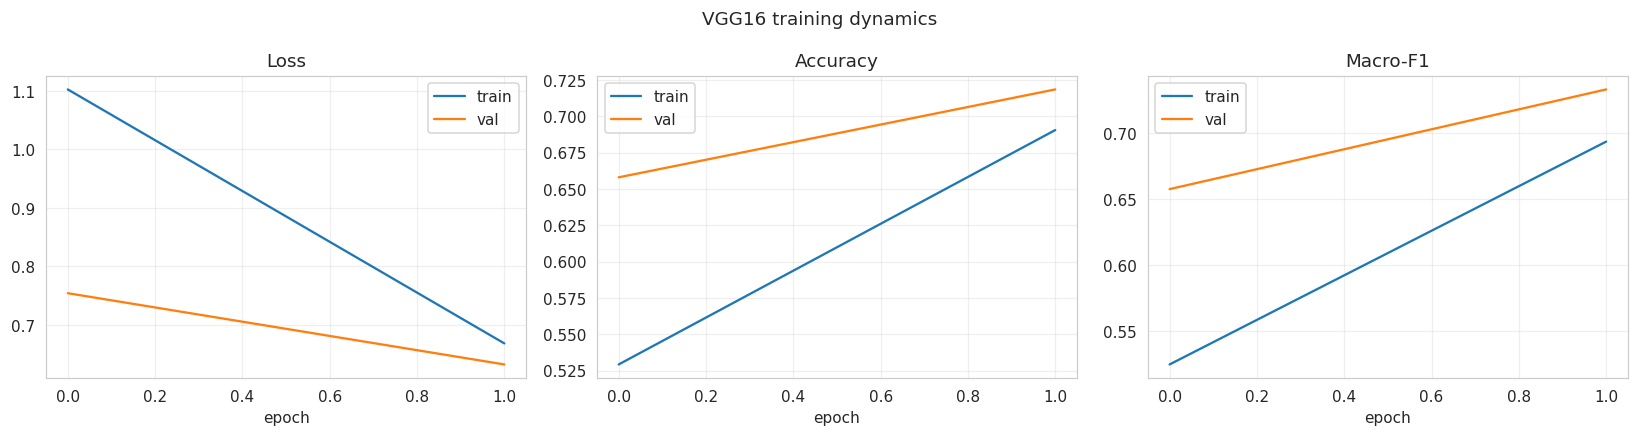

Training ResNet50  (hp={'lr': 0.0001, 'weight_decay': 0.0001, 'batch_size': 32}) ...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


  epoch 1/2  train_loss 0.723  val_loss 0.524  val_f1 0.784  val_acc 0.761
  epoch 2/2  train_loss 0.499  val_loss 0.596  val_f1 0.745  val_acc 0.734
ResNet50 val macro-F1: 0.784


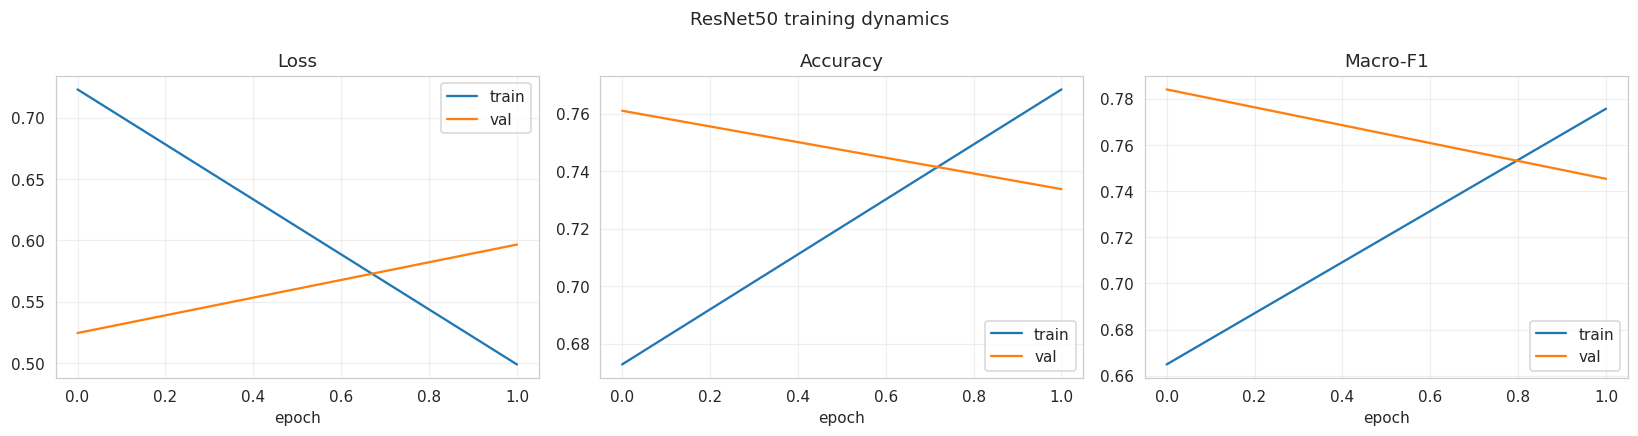

In [21]:
def default_or_tuned(name):
    # Optional GWO tuning of a baseline, mirroring the ViT routine.
    if not TUNE_BASELINES:
        return dict(lr=1e-4, weight_decay=1e-4, batch_size=DEFAULT_BATCH)
    space = {'lr':[1e-4,3e-5], 'weight_decay':[1e-4,1e-5], 'batch_size':[16,32]}
    keys = list(space.keys())
    def fit(sol):
        hp = {k: space[k][int(v)%2] for k,v in zip(keys,sol)}
        tl, vl = make_loaders(hp['batch_size'], tune=True)
        _,_,f = train_model(build_cnn(name), tl, vl, epochs=TUNE_EPOCHS,
                            lr=hp['lr'], weight_decay=hp['weight_decay'],
                            patience=TUNE_EPOCHS, verbose=False)
        return 1 - f
    prob = {'obj_func':fit, 'bounds':FloatVar(lb=[0.]*3, ub=[1.999]*3), 'minmax':'min', 'log_to':None}
    g = GWO.OriginalGWO(epoch=GWO_ITERATIONS, pop_size=GWO_POP_SIZE).solve(prob)
    return {k: space[k][int(v)%2] for k,v in zip(keys, g.solution)}

baseline_models, baseline_hist = {}, {}
for name in ['MobileNetV2', 'VGG16', 'ResNet50']:
    hp = default_or_tuned(name)
    print(f'Training {name}  (hp={hp}) ...')
    tl, vl = make_loaders(hp['batch_size'], tune=False)
    m, h, bf1 = train_model(build_cnn(name), tl, vl, epochs=2,
                            lr=hp['lr'], weight_decay=hp['weight_decay'])
    baseline_models[name], baseline_hist[name] = m, h
    print(name, 'val macro-F1:', round(bf1, 4))
    plot_history(h, name + ' training dynamics')

## 4 & 5. Evaluation on the held-out test set

Confusion matrices, per-class precision/recall/F1, and macro/weighted metrics (macro-averaging emphasized due to imbalance).

In [22]:
test_loader = DataLoader(MaizeDataset(test_df, eval_tf), batch_size=DEFAULT_BATCH,
                         shuffle=False, num_workers=2)

def full_metrics(model, name):
    probs, labels = get_probs(model, test_loader)
    preds = probs.argmax(1)
    p, r, f1, _   = precision_recall_fscore_support(labels, preds, average='macro',    zero_division=0)
    _, _, f1w, _  = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=0)
    try:
        yb = label_binarize(labels, classes=list(range(len(TARGET_CLASSES))))
        auc = roc_auc_score(yb, probs, average='macro', multi_class='ovr')
    except Exception:
        auc = float('nan')
    return {'model':name, 'accuracy':accuracy_score(labels, preds),
            'macro_precision':p, 'macro_recall':r, 'macro_f1':f1, 'weighted_f1':f1w,
            'auc_ovr':auc, 'probs':probs, 'labels':labels, 'preds':preds}

all_models = {'ViT-B/16 (GWO)': vit, **baseline_models}
results = {name: full_metrics(m, name) for name, m in all_models.items()}
print('Evaluated:', list(results.keys()))

Evaluated: ['ViT-B/16 (GWO)', 'MobileNetV2', 'VGG16', 'ResNet50']


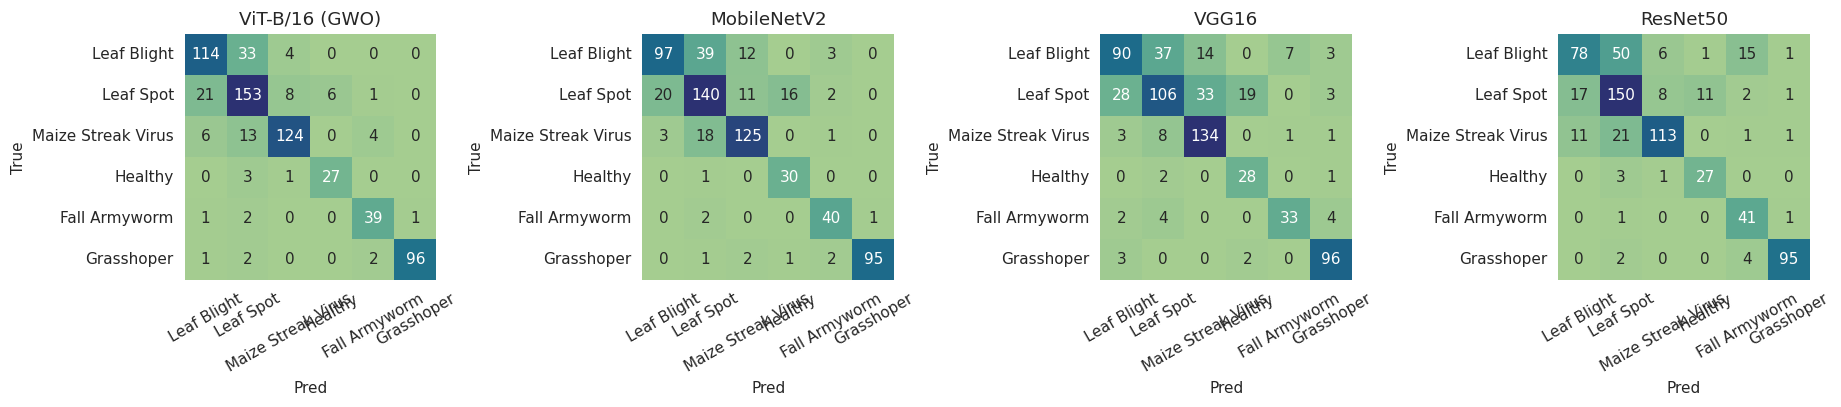

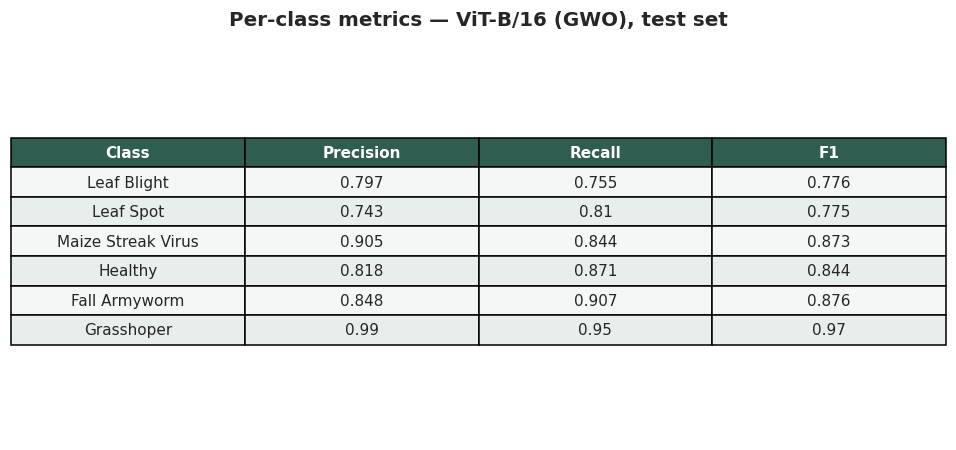

In [23]:
labels_names = [CLASS_DISPLAY[c] for c in TARGET_CLASSES]
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(4.2*n, 3.8))
for ax, (name, res) in zip(np.atleast_1d(axes), results.items()):
    cm = confusion_matrix(res['labels'], res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest', cbar=False,
                xticklabels=labels_names, yticklabels=labels_names, ax=ax)
    ax.set_title(name); ax.set_xlabel('Pred'); ax.set_ylabel('True'); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

# Per-class metrics table for the primary model
res = results['ViT-B/16 (GWO)']
rep = classification_report(res['labels'], res['preds'], target_names=labels_names,
                            output_dict=True, zero_division=0)
render_table(pd.DataFrame({
    'Class'    : labels_names,
    'Precision': [round(rep[l]['precision'], 3) for l in labels_names],
    'Recall'   : [round(rep[l]['recall'],    3) for l in labels_names],
    'F1'       : [round(rep[l]['f1-score'],  3) for l in labels_names],
}), title='Per-class metrics — ViT-B/16 (GWO), test set')

### 3.7 Complementary SqueezeNet stream with GWO-weighted late fusion

SqueezeNet is added **beside** the ViT (never inside it) and combined only at the decision level:

$$P_{final} = w\,P_{ViT} + (1-w)\,P_{SqueezeNet}$$

GWO optimizes the fusion weight *w* on the **validation** set. **No-compromise guarantee:** because *w = 1* reproduces the ViT exactly, we clamp the chosen weight so validation macro-F1 can only **tie or improve** the ViT-alone result; the final *w* is then reported once on the test set.

Training SqueezeNet (frozen features + softmax head)...
  epoch 1/3  train_loss 1.109  val_loss 0.791  val_f1 0.656  val_acc 0.673
  epoch 2/3  train_loss 0.785  val_loss 0.750  val_f1 0.698  val_acc 0.703
  epoch 3/3  train_loss 0.706  val_loss 0.769  val_f1 0.675  val_acc 0.678
SqueezeNet val macro-F1: 0.6975


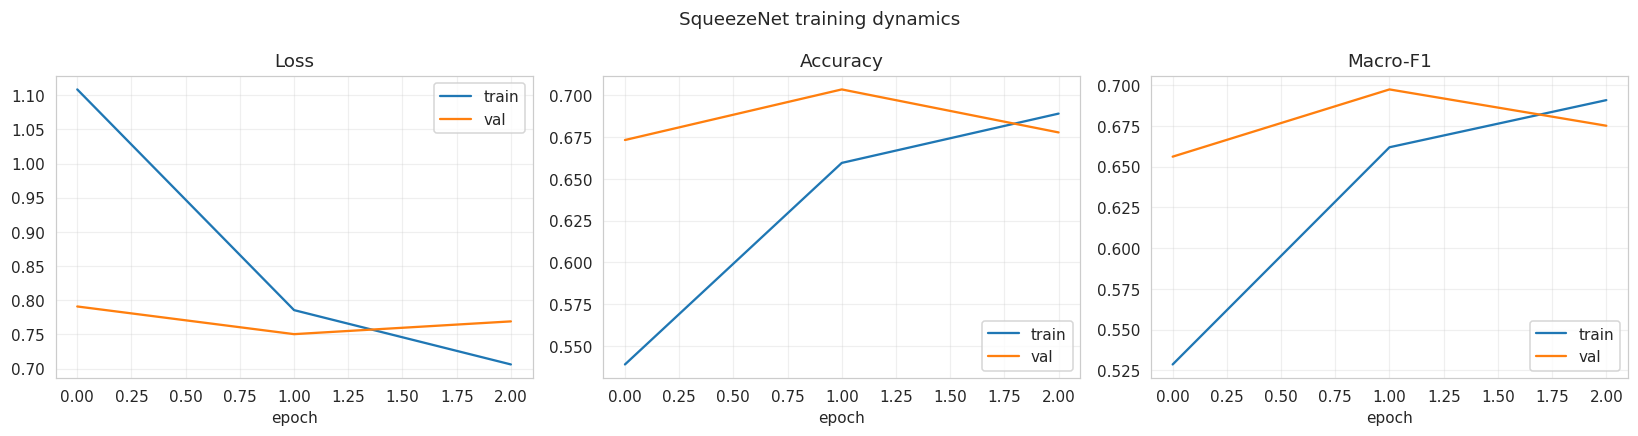

GWO weight w=0.827 (val F1 0.8715) | ViT-alone val F1 0.8669 | using w=0.827
{'model': 'ViT+SqueezeNet (GWO fusion)', 'accuracy': 0.8383685800604229, 'macro_f1': 0.8539691371468389, 'weighted_f1': 0.839276027308403}


In [25]:
print('Training SqueezeNet (frozen features + softmax head)...')
tl, vl = make_loaders(DEFAULT_BATCH, tune=False)
sqz, sqz_hist, sqz_bestf1 = train_model(build_squeezenet(), tl, vl, epochs=FINAL_EPOCHS,
                                        lr=1e-3, weight_decay=1e-4)
print('SqueezeNet val macro-F1:', round(sqz_bestf1, 4))
plot_history(sqz_hist, 'SqueezeNet training dynamics')

# Probability vectors on validation (for weight search) and test (final report)
vit_val_p,  val_labels  = get_probs(vit, val_loader)
sqz_val_p,  _           = get_probs(sqz, val_loader)
vit_test_p, test_labels = get_probs(vit, test_loader)
sqz_test_p, _           = get_probs(sqz, test_loader)

def fusion_fitness(sol):
    w = float(sol[0])
    fused = w*vit_val_p + (1-w)*sqz_val_p
    return 1 - f1_score(val_labels, fused.argmax(1), average='macro')

fprob = {'obj_func':fusion_fitness, 'bounds':FloatVar(lb=[0.0], ub=[1.0]),
         'minmax':'min', 'log_to':None}
fbest = GWO.OriginalGWO(epoch=10, pop_size=8).solve(fprob)
w_found = float(fbest.solution[0])

# No-compromise clamp: never worse than ViT-alone (w = 1) on validation
f1_found    = 1 - fusion_fitness([w_found])
f1_vitalone = f1_score(val_labels, vit_val_p.argmax(1), average='macro')
w_star = w_found if f1_found >= f1_vitalone else 1.0
print(f'GWO weight w={w_found:.3f} (val F1 {f1_found:.4f}) | ViT-alone val F1 {f1_vitalone:.4f} | using w={w_star:.3f}')

fused_test  = w_star*vit_test_p + (1-w_star)*sqz_test_p
fused_preds = fused_test.argmax(1)
fused_metrics = {
    'model'      : 'ViT+SqueezeNet (GWO fusion)',
    'accuracy'   : accuracy_score(test_labels, fused_preds),
    'macro_f1'   : f1_score(test_labels, fused_preds, average='macro'),
    'weighted_f1': f1_score(test_labels, fused_preds, average='weighted'),
}
print(fused_metrics)

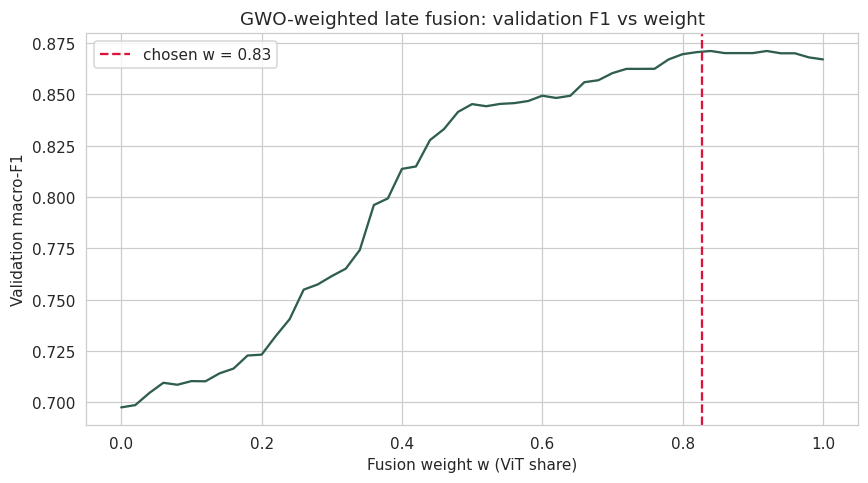

In [26]:
# Fusion weight sweep on validation (visual)
ws = np.linspace(0, 1, 51)
val_f1s = [f1_score(val_labels, (w*vit_val_p + (1-w)*sqz_val_p).argmax(1), average='macro') for w in ws]
plt.figure(figsize=(8, 4.5))
plt.plot(ws, val_f1s, color='#2f5d50')
plt.axvline(w_star, ls='--', color='crimson', label=f'chosen w = {w_star:.2f}')
plt.xlabel('Fusion weight w (ViT share)'); plt.ylabel('Validation macro-F1')
plt.title('GWO-weighted late fusion: validation F1 vs weight'); plt.legend()
plt.tight_layout(); plt.show()

## 6. Comparative analysis, efficiency & deliverables

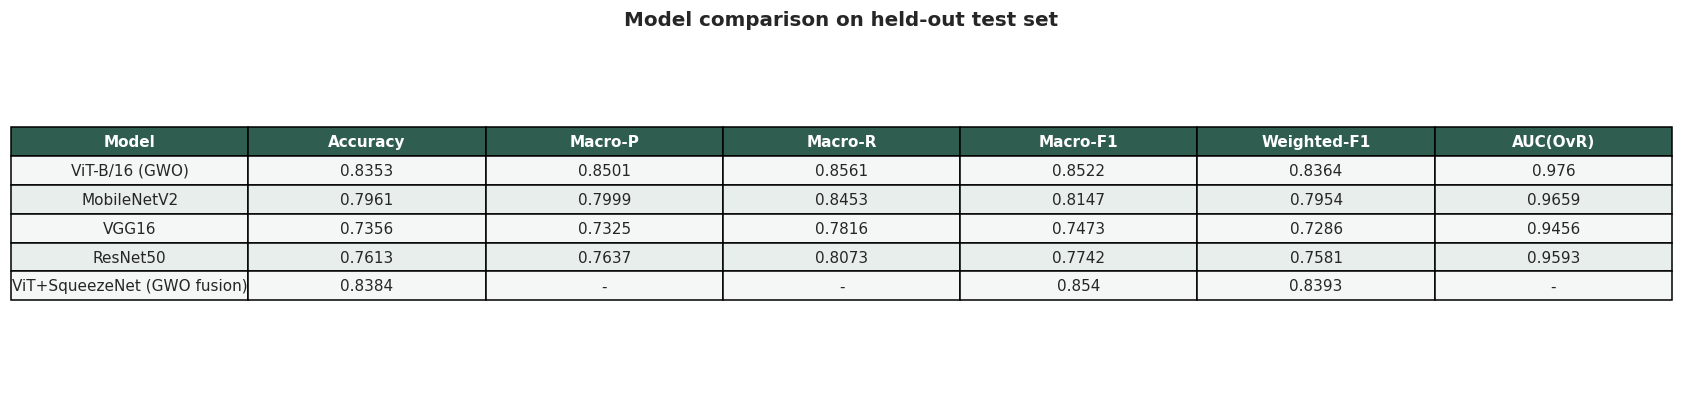

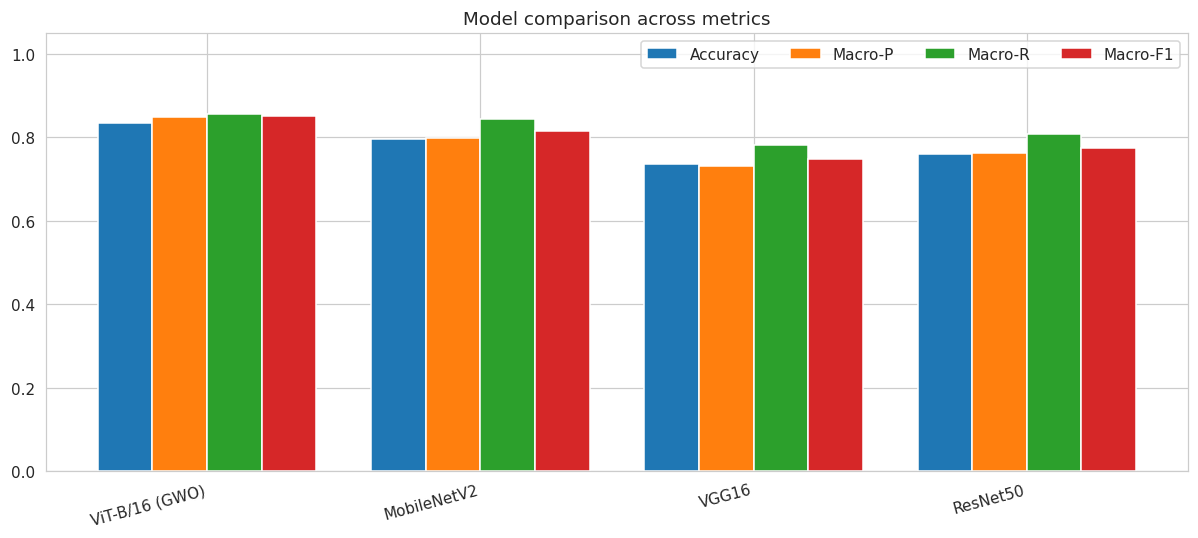

In [27]:
comp = pd.DataFrame([{
    'Model'      : r['model'],
    'Accuracy'   : round(r['accuracy'], 4),
    'Macro-P'    : round(r['macro_precision'], 4),
    'Macro-R'    : round(r['macro_recall'], 4),
    'Macro-F1'   : round(r['macro_f1'], 4),
    'Weighted-F1': round(r['weighted_f1'], 4),
    'AUC(OvR)'   : round(r['auc_ovr'], 4),
} for r in results.values()])
comp = pd.concat([comp, pd.DataFrame([{
    'Model':fused_metrics['model'], 'Accuracy':round(fused_metrics['accuracy'],4),
    'Macro-P':np.nan, 'Macro-R':np.nan, 'Macro-F1':round(fused_metrics['macro_f1'],4),
    'Weighted-F1':round(fused_metrics['weighted_f1'],4), 'AUC(OvR)':np.nan}])],
    ignore_index=True)
render_table(comp.fillna('-'), title='Model comparison on held-out test set')

metrics_to_plot = ['Accuracy', 'Macro-P', 'Macro-R', 'Macro-F1']
plot_df = comp.dropna(subset=['Macro-P'])
x = np.arange(len(plot_df)); w = 0.2
fig, ax = plt.subplots(figsize=(11, 5))
for i, mt in enumerate(metrics_to_plot):
    ax.bar(x + (i-1.5)*w, plot_df[mt], w, label=mt)
ax.set_xticks(x); ax.set_xticklabels(plot_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.05); ax.set_title('Model comparison across metrics'); ax.legend(ncol=4)
plt.tight_layout(); plt.show()

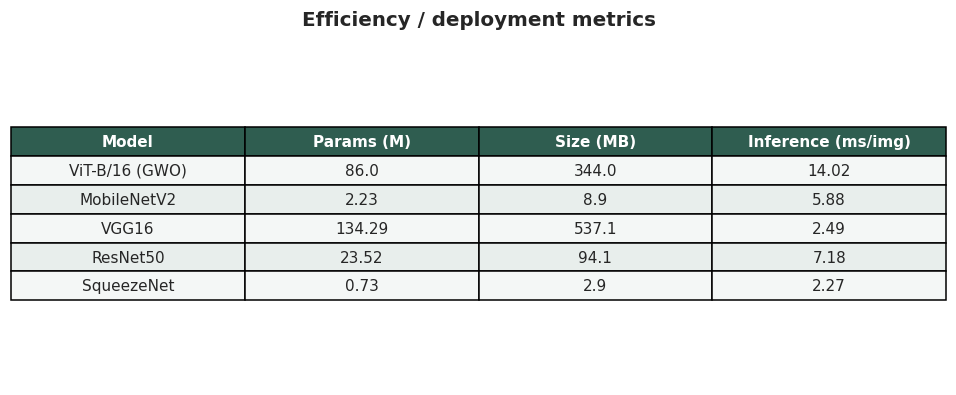

In [28]:
# Efficiency / deployment metrics
eff_rows = []
for name, m in list(all_models.items()) + [('SqueezeNet', sqz)]:
    m.eval(); xb = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    with torch.no_grad():
        for _ in range(3): m(xb)                 # warmup
        t0 = time.time()
        for _ in range(20): m(xb)
        dt = (time.time() - t0) / 20 * 1000
    n = count_params(m)
    eff_rows.append({'Model':name, 'Params (M)':round(n/1e6, 2),
                     'Size (MB)':round(n*4/1e6, 1), 'Inference (ms/img)':round(dt, 2)})
render_table(pd.DataFrame(eff_rows), title='Efficiency / deployment metrics')

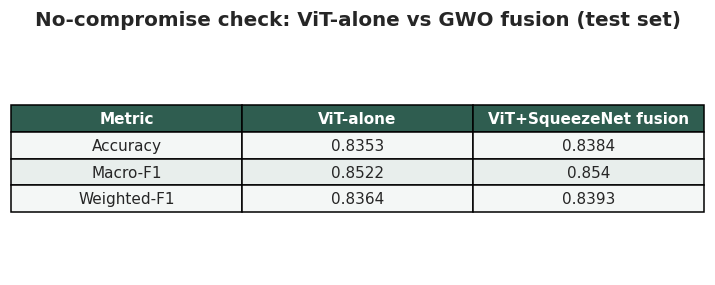

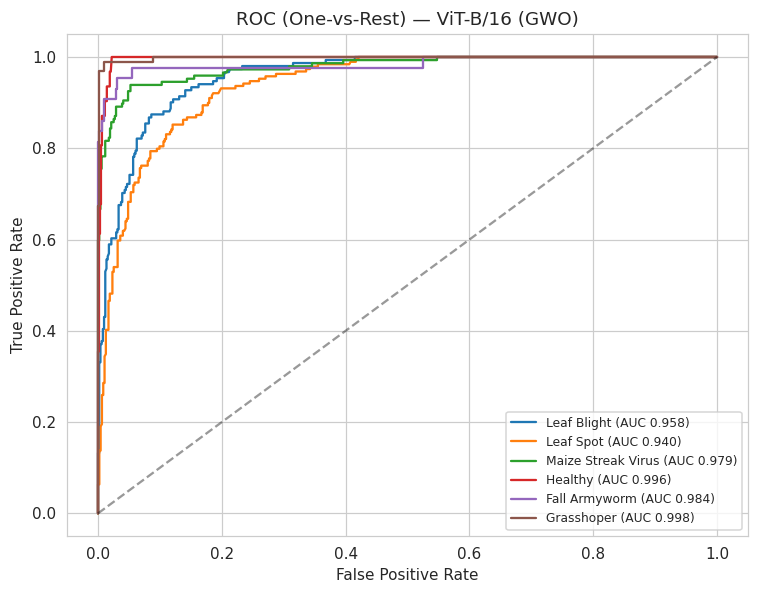

In [29]:
# No-compromise check + ROC (OvR) for the primary model
vf = results['ViT-B/16 (GWO)']
render_table(pd.DataFrame({
    'Metric'                : ['Accuracy', 'Macro-F1', 'Weighted-F1'],
    'ViT-alone'             : [round(vf['accuracy'],4), round(vf['macro_f1'],4), round(vf['weighted_f1'],4)],
    'ViT+SqueezeNet fusion' : [round(fused_metrics['accuracy'],4), round(fused_metrics['macro_f1'],4), round(fused_metrics['weighted_f1'],4)],
}), title='No-compromise check: ViT-alone vs GWO fusion (test set)')

yb = label_binarize(vf['labels'], classes=list(range(len(TARGET_CLASSES))))
plt.figure(figsize=(7, 5.5))
for i, c in enumerate(TARGET_CLASSES):
    fpr, tpr, _ = roc_curve(yb[:, i], vf['probs'][:, i])
    plt.plot(fpr, tpr, label=f'{CLASS_DISPLAY[c]} (AUC {roc_auc_score(yb[:,i], vf["probs"][:,i]):.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC (One-vs-Rest) — ViT-B/16 (GWO)'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

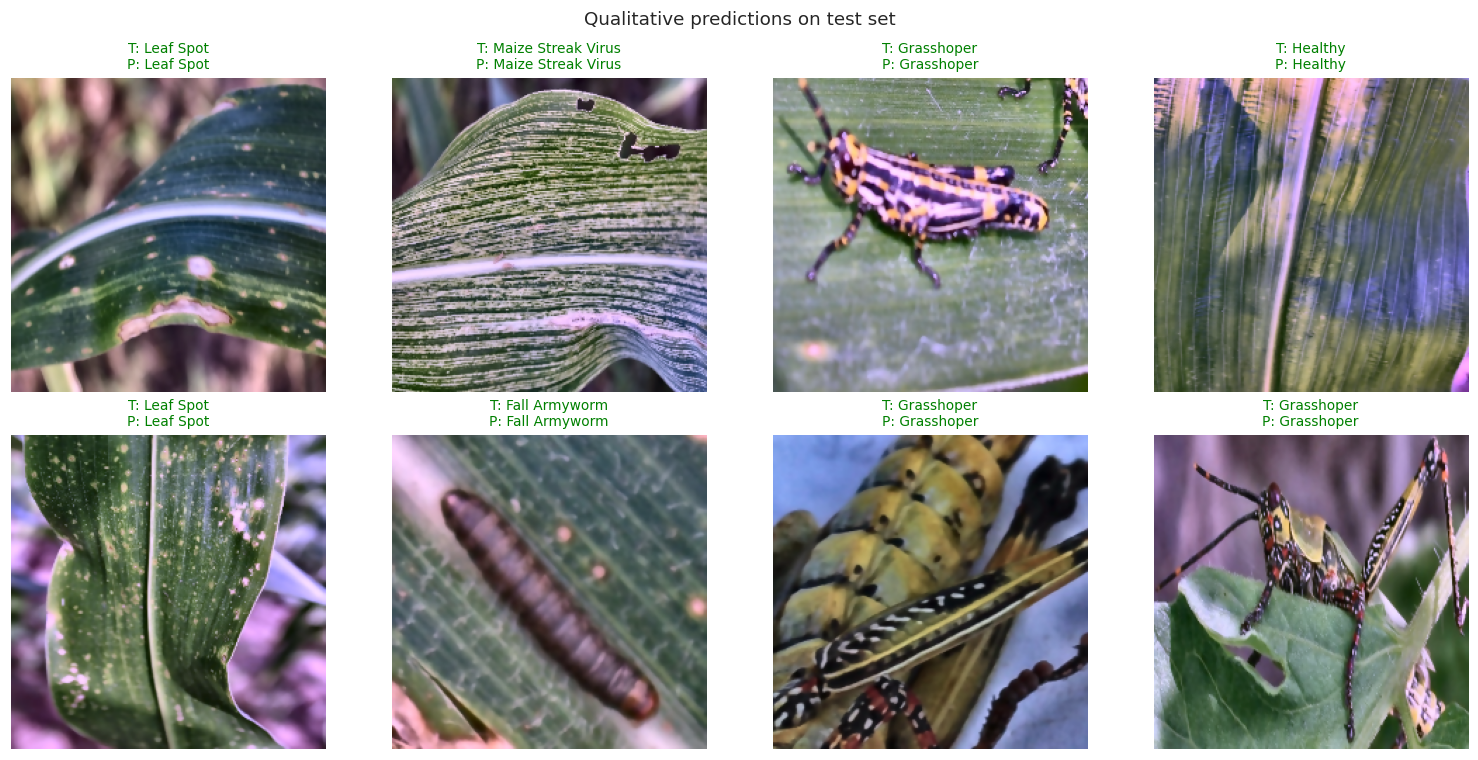

In [30]:
# Qualitative predictions on the test set (true vs predicted)
sel = np.random.RandomState(SEED).choice(len(test_df), size=min(8, len(test_df)), replace=False)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.ravel(), sel):
    im = preprocess_image(load_rgb(test_df.iloc[idx]['filepath']))
    ax.imshow(im); ax.axis('off')
    t = CLASS_DISPLAY[IDX_TO_CLASS[vf['labels'][idx]]]
    p = CLASS_DISPLAY[IDX_TO_CLASS[vf['preds'][idx]]]
    ax.set_title(f'T: {t}\nP: {p}', color=('green' if t == p else 'red'), fontsize=9)
fig.suptitle('Qualitative predictions on test set', fontsize=12)
plt.tight_layout(); plt.show()

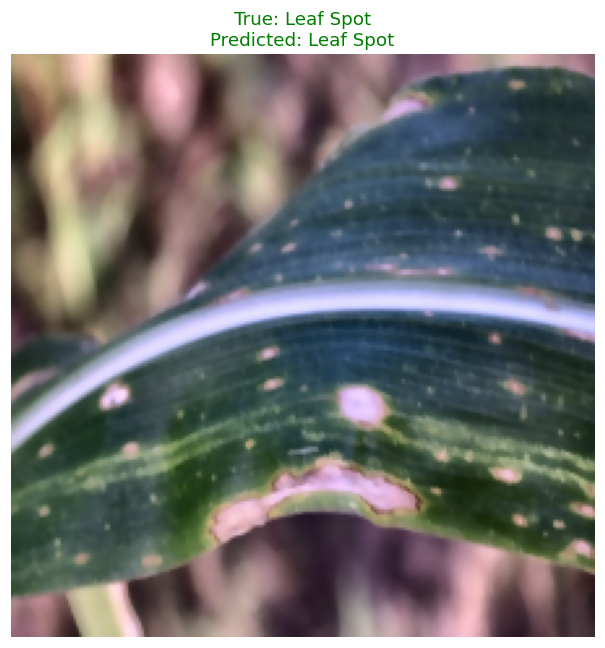

In [31]:
sample_idx = np.random.RandomState(SEED).choice(len(test_df), size=1, replace=False)[0]
sample_row = test_df.iloc[sample_idx]
sample_filepath = sample_row['filepath']
sample_true_class = CLASS_DISPLAY[sample_row['class']]

# Load and preprocess the image
img = load_rgb(sample_filepath)
processed_img = preprocess_image(img, segment=USE_SEGMENTATION_IN_PIPELINE)

# Transform for model input
input_tensor = eval_tf(processed_img).unsqueeze(0) # Add batch dimension

# Move to device and get prediction
vit.eval() # Set model to evaluation mode
with torch.no_grad():
    output = vit(input_tensor.to(device))
    probabilities = torch.softmax(output, dim=1)
    predicted_idx = torch.argmax(probabilities, dim=1).item()

predicted_class = CLASS_DISPLAY[IDX_TO_CLASS[predicted_idx]]

# Display the image and prediction
plt.figure(figsize=(6, 6))
plt.imshow(processed_img)
plt.title(f"True: {sample_true_class}\nPredicted: {predicted_class}",
          color=('green' if sample_true_class == predicted_class else 'red'))
plt.axis('off')
plt.tight_layout()
plt.show()

## 7. Summary & deliverables

- **GWO-tuned ViT-B/16** on recent, field-collected maize imagery, with the optimal hyperparameter set discovered by the optimizer.
- **Comparative analysis** vs MobileNetV2 / VGG16 / ResNet50 on accuracy *and* efficiency.
- **GWO-weighted ViT + SqueezeNet fusion**, reported against ViT-alone with a **no-compromise guarantee** (can tie or improve, never degrade).
- Fully visualized pipeline — preprocessing panels, augmentation grid, **GWO convergence curve**, training dynamics, confusion matrices, ROC, and matplotlib tables at every stage.

**Optional extensions**
- *Attention-map overlays*: extract ViT attention from the last block to visualize attended leaf regions.
- *7-class task*: re-include the three pest folders by extending `match_target_class` / `TARGET_CLASSES`.
- *Fair-budget baselines*: set `TUNE_BASELINES = True` to GWO-tune every model equally.
- *Deployment*: export the ViT (or the lighter fusion) to TorchScript / ONNX for mobile/web inference.